# Identifiability Analysis — AV Duration Estimation

This notebook summarises the model-identifiability analyses done in response to the eLife desk rejection. The editors requested simulations showing under which conditions the competing models can be disentangled.

**Sections**
1. Participant sensory noise estimates (σ_a, σ_v) from model fits  
2. Model comparison — AIC / BIC across participants  
3. Why the empirical regime limits identifiability  
4. Divergence diagnostic — cheap identifiability landscape  
5. Model-recovery sweep — diagonal recovery vs (σ, conflict range)  
6. Confusion matrices per regime  
7. PSE-curve separation by regime  

In [17]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import glob

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

MODEL_ABBR = {
    'lognorm':                    'CI',
    'fusionOnlyLogNorm':          'Fusion',
    'switchingFree':              'Switching',
    'probabilityMatchingLogNorm': 'Prob. Match.',
    'selection':                  'Selection',
}
MODEL_COLORS = {
    'lognorm':                    '#1f77b4',
    'fusionOnlyLogNorm':          '#ff7f0e',
    'switchingFree':              '#2ca02c',
    'probabilityMatchingLogNorm': '#d62728',
    'selection':                  '#9467bd',
}

FITS_DIR = 'model_fits'
MODELS   = ['lognorm', 'fusionOnlyLogNorm', 'switchingFree',
             'probabilityMatchingLogNorm', 'selection']

# Full-vector param layouts (sharedLambda=True)
# lognorm:           [λ, σa1, σv, p_c, σa2]
# fusionOnlyLogNorm: [λ, σa1, σv, σa2]
# switchingFree:     [λ, σa1, σv, p_sw1, σa2, p_sw2]
# probabilityMatchingLogNorm / selection: same as lognorm
PARAM_IDX = {
    'lambda': {m: 0 for m in MODELS},
    'sigma_a1': {m: 1 for m in MODELS},          # low-noise condition
    'sigma_v':  {m: 2 for m in MODELS},
    'sigma_a2': {'lognorm': 4, 'fusionOnlyLogNorm': 3,
                 'switchingFree': 4, 'probabilityMatchingLogNorm': 4,
                 'selection': 4},
    'p_c':      {'lognorm': 3, 'probabilityMatchingLogNorm': 3, 'selection': 3},
    'p_sw1':    {'switchingFree': 3},
}

def load_fits():
    pids = sorted([d for d in os.listdir(FITS_DIR)
                   if os.path.isdir(os.path.join(FITS_DIR, d))
                   and d not in ['.DS_Store', 'all']])
    rows = []
    for pid in pids:
        for model in MODELS:
            suffix = f'{model}_LapseFix_sharedPrior'
            fp = os.path.join(FITS_DIR, pid, f'{pid}_{suffix}_fit.json')
            if not os.path.exists(fp):
                continue
            with open(fp) as f:
                r = json.load(f)
            p = r['fittedParams']
            row = dict(pid=pid, model=model,
                       AIC=r['AIC'], BIC=r['BIC'], LL=r['logLikelihood'],
                       nParams=len(p),
                       lam=p[0], sigma_a1=p[1], sigma_v=p[2],
                       sigma_a2=p[PARAM_IDX['sigma_a2'][model]] if model in PARAM_IDX['sigma_a2'] else np.nan,
                       sigma_a_mean=np.mean([p[1], p[PARAM_IDX['sigma_a2'][model]]]) if model in PARAM_IDX['sigma_a2'] else p[1],
                       p_c=p[3] if model in ['lognorm','probabilityMatchingLogNorm','selection'] else np.nan,
                       p_sw=p[3] if model == 'switchingFree' else np.nan)
            rows.append(row)
    return pd.DataFrame(rows)

df = load_fits()
print(f'Loaded {df["pid"].nunique()} participants × {df["model"].nunique()} models = {len(df)} fits')
df.head(6)

Loaded 11 participants × 5 models = 55 fits


,pid,model,AIC,BIC,LL,nParams,lam,sigma_a1,sigma_v,sigma_a2,sigma_a_mean,p_c,p_sw
0,P01,lognorm,2248.748703,2268.985563,-1119.374351,5,0.054969,0.241329,0.606782,0.632321,0.436825,1.000000,NaN
1,P01,fusionOnlyLogNorm,2246.437345,2262.626834,-1119.218672,4,0.054879,0.238490,0.593979,0.579842,0.409166,NaN,NaN
2,P01,switchingFree,2251.087865,2275.372098,-1119.543933,6,0.041798,0.248199,0.000113,0.577344,0.412772,NaN,0.092697
3,P01,probabilityMatchingLogNorm,2249.399181,2269.636042,-1119.699590,5,0.052201,0.241990,0.589356,0.616575,0.429283,0.000003,NaN
4,P01,selection,2255.129539,2275.366400,-1122.564769,5,0.011277,0.135116,0.318739,0.295883,0.215500,0.736245,NaN
5,P02,lognorm,2549.546215,2570.114626,-1269.773107,5,0.246876,0.217073,0.335323,0.582083,0.399578,0.608586,NaN


## 1. Sensory noise estimates per participant

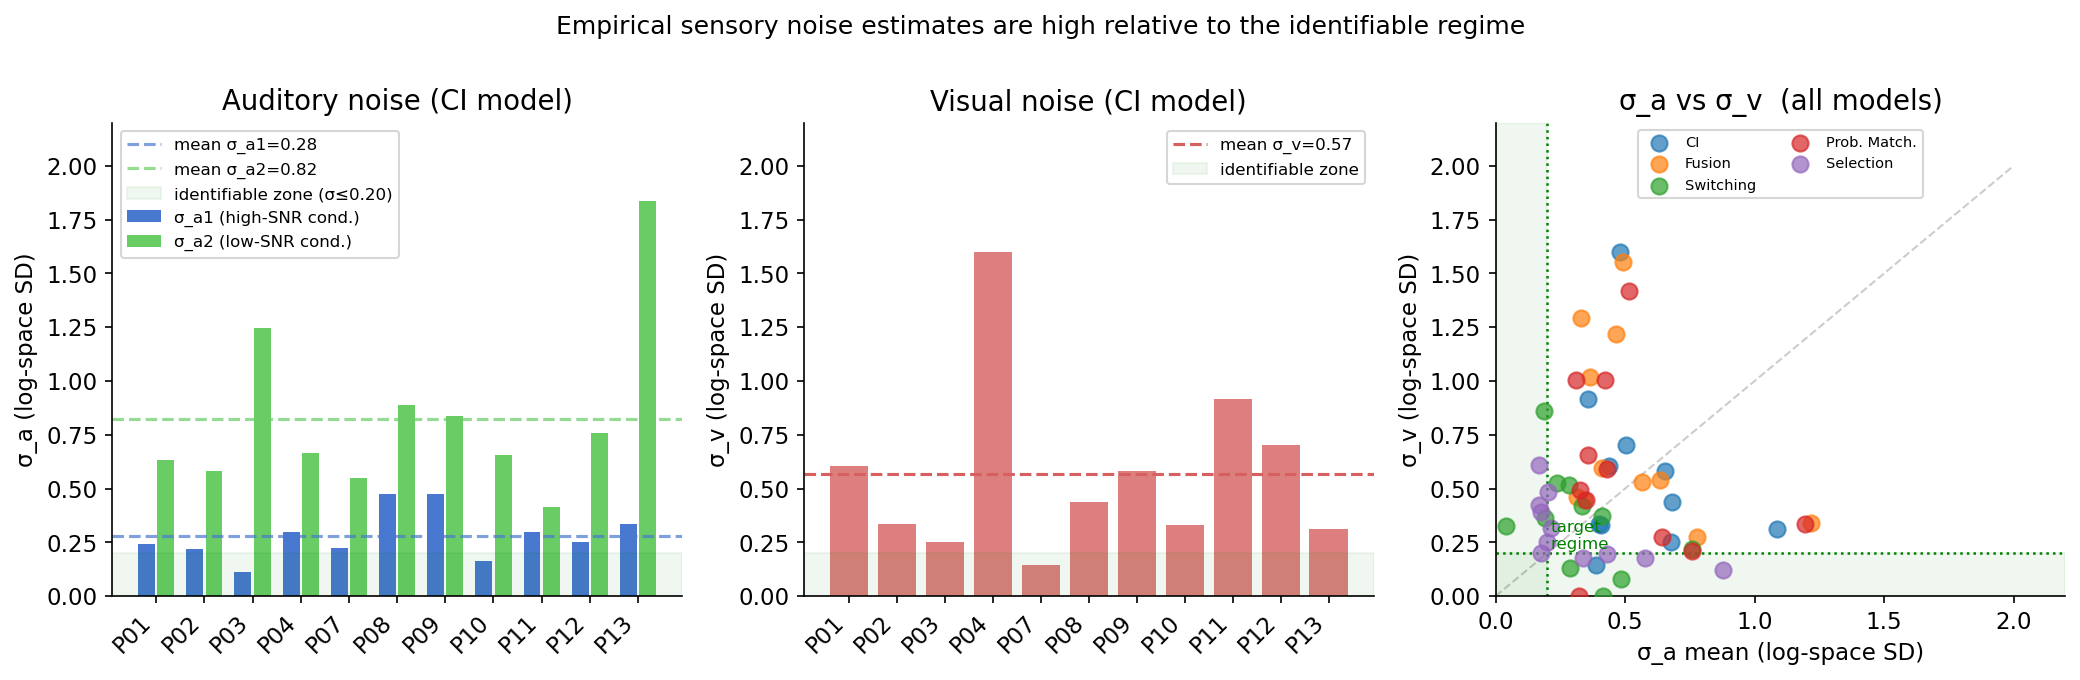

In [18]:
# Use lognorm (CI) as the reference model for displaying σ estimates
ci_df = df[df['model'] == 'lognorm'].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- Panel A: σ_a (mean across both SNR conditions) per participant ---
ax = axes[0]
x = np.arange(len(ci_df))
ax.bar(x - 0.2, ci_df['sigma_a1'].values, 0.35, label='σ_a1 (high-SNR cond.)', color='#4878cf')
ax.bar(x + 0.2, ci_df['sigma_a2'].values, 0.35, label='σ_a2 (low-SNR cond.)',  color='#6acc65')
ax.axhline(ci_df['sigma_a1'].mean(), ls='--', color='#4878cf', alpha=0.7,
           label=f'mean σ_a1={ci_df["sigma_a1"].mean():.2f}')
ax.axhline(ci_df['sigma_a2'].mean(), ls='--', color='#6acc65', alpha=0.7,
           label=f'mean σ_a2={ci_df["sigma_a2"].mean():.2f}')
# shade the identifiable zone
ax.axhspan(0, 0.20, color='green', alpha=0.06, label='identifiable zone (σ≤0.20)')
ax.set_xticks(x); ax.set_xticklabels(ci_df['pid'].values, rotation=45, ha='right')
ax.set_ylabel('σ_a (log-space SD)')
ax.set_title('Auditory noise (CI model)')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(0, 2.2)

# --- Panel B: σ_v per participant ---
ax = axes[1]
ax.bar(x, ci_df['sigma_v'].values, color='#d65f5f', alpha=0.8)
ax.axhline(ci_df['sigma_v'].mean(), ls='--', color='#d65f5f',
           label=f'mean σ_v={ci_df["sigma_v"].mean():.2f}')
ax.axhspan(0, 0.20, color='green', alpha=0.06, label='identifiable zone')
ax.set_xticks(x); ax.set_xticklabels(ci_df['pid'].values, rotation=45, ha='right')
ax.set_ylabel('σ_v (log-space SD)')
ax.set_title('Visual noise (CI model)')
ax.legend(fontsize=8)
ax.set_ylim(0, 2.2)

# --- Panel C: scatter σ_a_mean vs σ_v per participant (all models) ---
ax = axes[2]
for model in MODELS:
    sub = df[df['model'] == model]
    ax.scatter(sub['sigma_a_mean'], sub['sigma_v'],
               label=MODEL_ABBR[model], color=MODEL_COLORS[model],
               s=60, alpha=0.7, zorder=3)
# Shade identifiable region
ax.axvspan(0, 0.20, color='green', alpha=0.06)
ax.axhspan(0, 0.20, color='green', alpha=0.06)
ax.axvline(0.20, ls=':', color='green', lw=1.2)
ax.axhline(0.20, ls=':', color='green', lw=1.2)
ax.text(0.21, 0.22, 'target\nregime', color='green', fontsize=8)
ax.plot([0, 2], [0, 2], 'k--', alpha=0.2, lw=1)
ax.set_xlabel('σ_a mean (log-space SD)')
ax.set_ylabel('σ_v (log-space SD)')
ax.set_title('σ_a vs σ_v  (all models)')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0, 2.2); ax.set_ylim(0, 2.2)

fig.suptitle('Empirical sensory noise estimates are high relative to the identifiable regime',
              fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig('identifiability_figures/fig_noise_estimates.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_noise_estimates.png', bbox_inches='tight', dpi=200)
plt.show()

## 2. Model comparison — AIC across participants

Best model per participant (AIC):
pid             model         AIC
P01 fusionOnlyLogNorm 2246.437345
P02         selection 2546.394308
P03         selection 1187.477990
P04     switchingFree 2401.432791
P07           lognorm 2167.374294
P08           lognorm 2438.929626
P09         selection 2491.127468
P10     switchingFree 2207.741391
P11     switchingFree 2319.577582
P12 fusionOnlyLogNorm 2498.542089
P13     switchingFree 2140.065402

Model wins:
model
switchingFree        4
selection            3
fusionOnlyLogNorm    2
lognorm              2
Name: count, dtype: int64


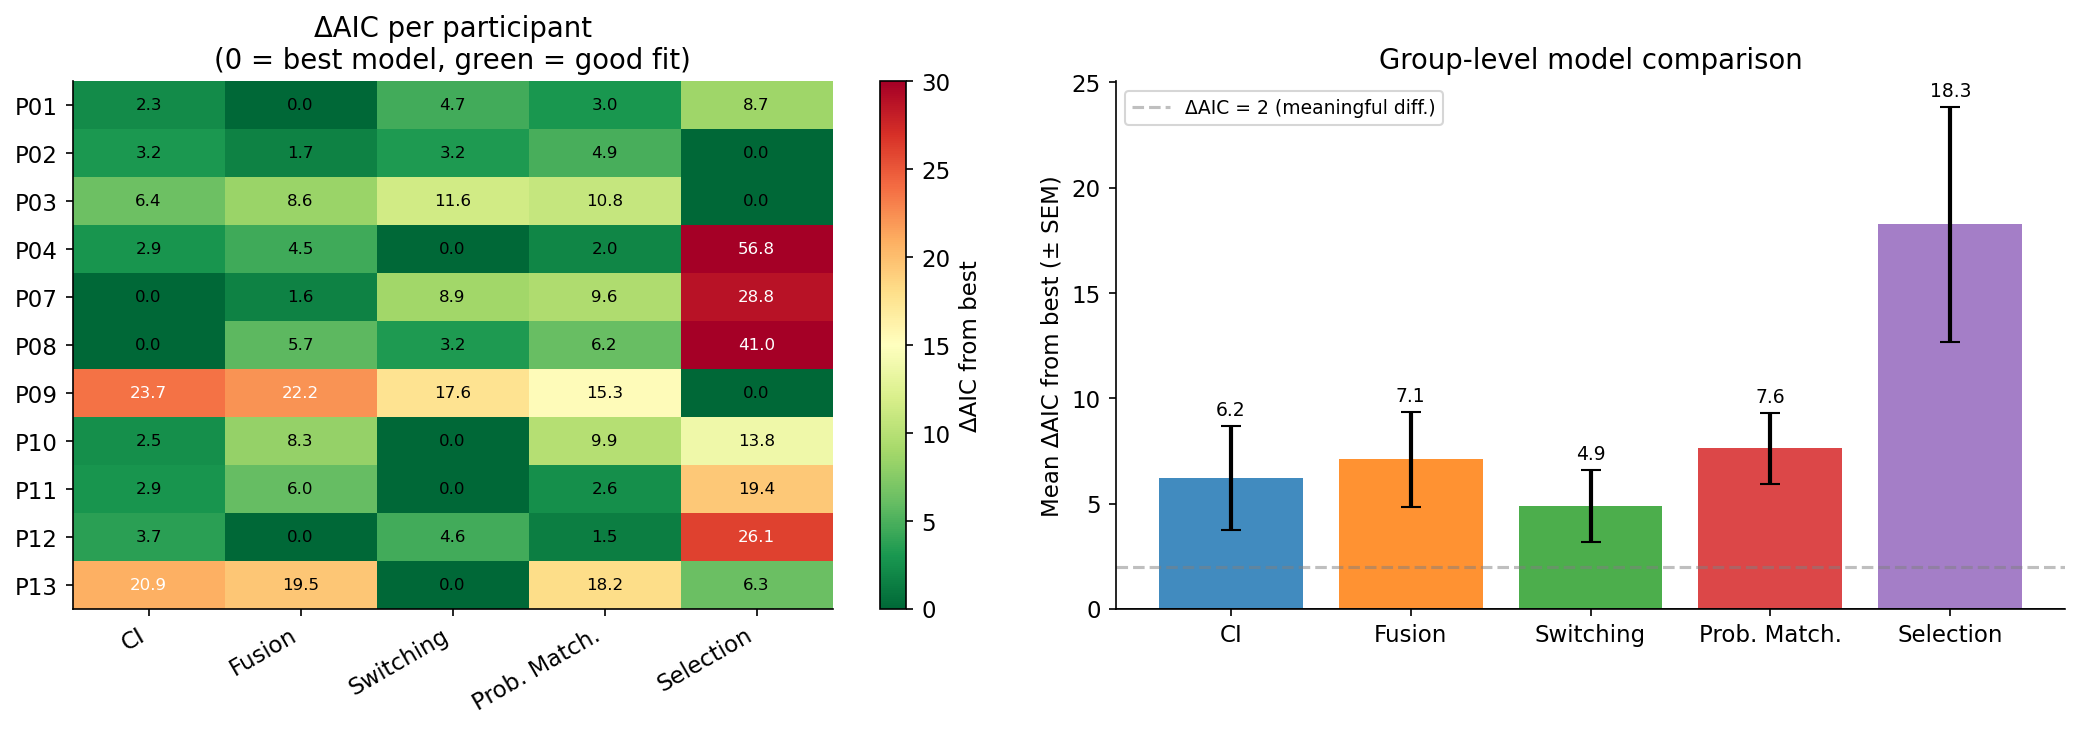

In [19]:
# Best model per participant (lowest AIC)
best = df.loc[df.groupby('pid')['AIC'].idxmin()][['pid', 'model', 'AIC']]
print('Best model per participant (AIC):')
print(best.to_string(index=False))
print()
print('Model wins:')
print(best['model'].value_counts())

# ΔAIC relative to best model per participant
df2 = df.copy()
df2['dAIC'] = df2.groupby('pid')['AIC'].transform(lambda x: x - x.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ΔAIC per participant (heatmap) ---
ax = axes[0]
pivot = df2.pivot(index='pid', columns='model', values='dAIC')
pivot.columns = [MODEL_ABBR[m] for m in pivot.columns]
pivot = pivot[['CI', 'Fusion', 'Switching', 'Prob. Match.', 'Selection']]
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=30)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                color='white' if v > 20 else 'black')
plt.colorbar(im, ax=ax, label='ΔAIC from best')
ax.set_title('ΔAIC per participant\n(0 = best model, green = good fit)')

# --- Right: Mean ΔAIC ± SEM ---
ax = axes[1]
means = df2.groupby('model')['dAIC'].agg(['mean', 'sem']).loc[MODELS]
abbrs = [MODEL_ABBR[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]
bars = ax.bar(abbrs, means['mean'], yerr=means['sem'], capsize=5,
               color=colors, alpha=0.85, error_kw={'lw': 2})
ax.set_ylabel('Mean ΔAIC from best (± SEM)')
ax.set_title('Group-level model comparison')
ax.axhline(2, ls='--', color='gray', alpha=0.5, label='ΔAIC = 2 (meaningful diff.)')
ax.axhline(0, ls='-', color='black', lw=0.8)
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, means.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row['sem'] + 0.3,
            f"{row['mean']:.1f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('identifiability_figures/fig_model_comparison_AIC.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_model_comparison_AIC.png', bbox_inches='tight', dpi=200)
plt.show()

## 3. p_c and p_switch estimates

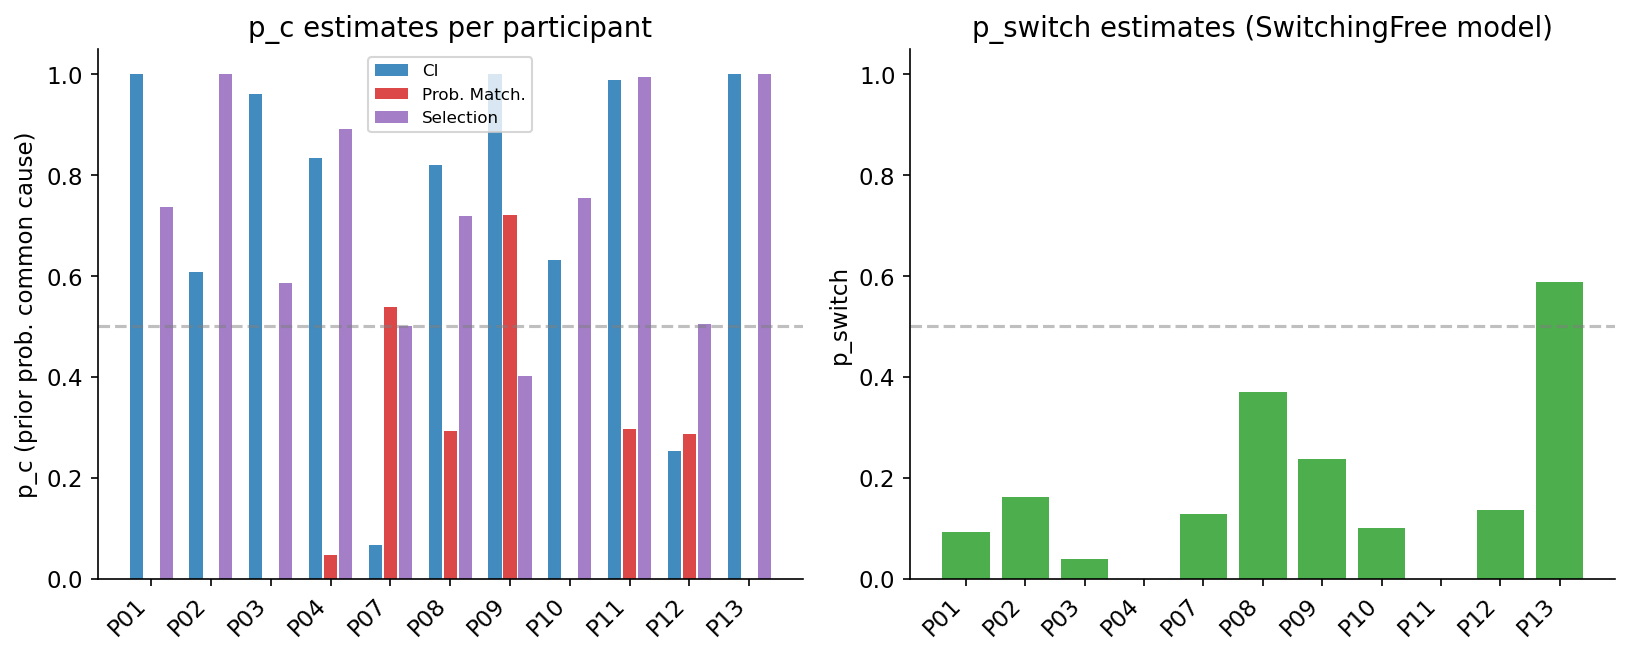

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# p_c for CI-like models
ax = axes[0]
pids_sorted = sorted(df['pid'].unique())
x = np.arange(len(pids_sorted))
for i, model in enumerate(['lognorm', 'probabilityMatchingLogNorm', 'selection']):
    sub = df[df['model'] == model].set_index('pid').reindex(pids_sorted)
    offset = (i - 1) * 0.25
    ax.bar(x + offset, sub['p_c'].values, 0.22,
           label=MODEL_ABBR[model], color=MODEL_COLORS[model], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pids_sorted, rotation=45, ha='right')
ax.set_ylabel('p_c (prior prob. common cause)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
ax.set_title('p_c estimates per participant')
ax.legend(fontsize=8)

# p_switch for switchingFree
ax = axes[1]
sw = df[df['model'] == 'switchingFree'].set_index('pid').reindex(pids_sorted)
ax.bar(x, sw['p_sw'].values, color=MODEL_COLORS['switchingFree'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(pids_sorted, rotation=45, ha='right')
ax.set_ylabel('p_switch')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
ax.set_title('p_switch estimates (SwitchingFree model)')

plt.tight_layout()
plt.savefig('identifiability_figures/fig_pc_estimates.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_pc_estimates.png', bbox_inches='tight', dpi=200)
plt.show()

## 4. Divergence diagnostic — identifiability landscape

For each (σ, conflict_max) cell we compute the mean absolute difference in predicted p(test_longer) across all stimulus conditions and all model pairs. This requires no fitting and gives a smooth landscape.

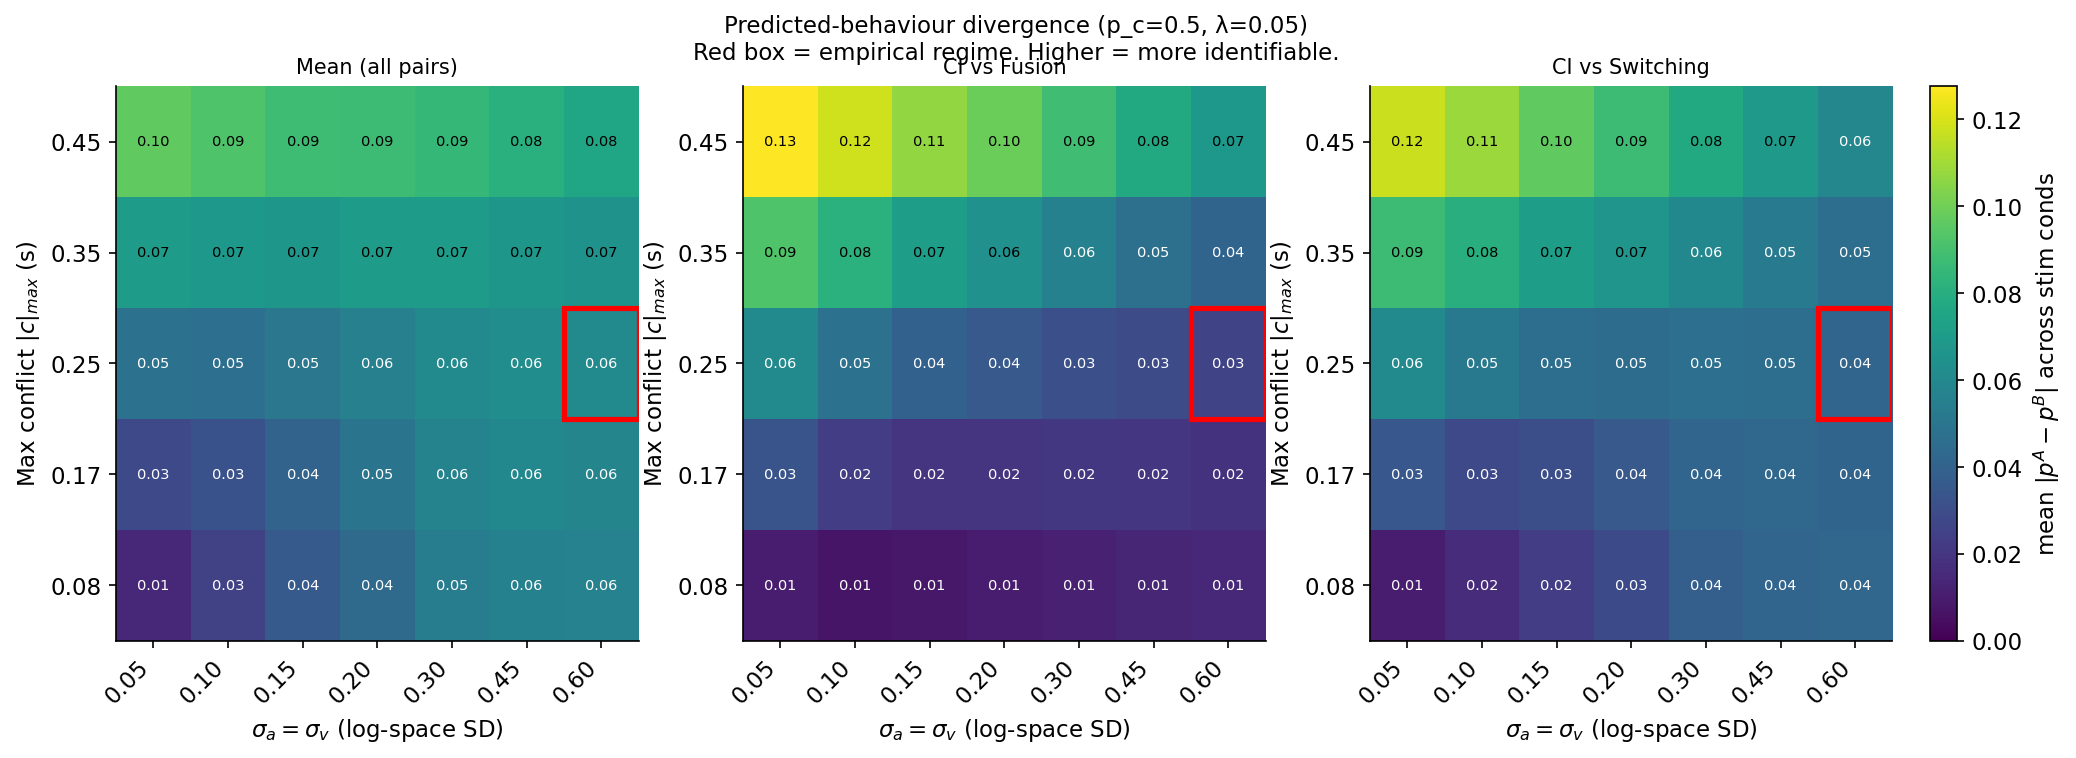

Empirical regime  (σ≈0.60, cmax=0.25): divergence = 0.061
Low-noise regime  (σ=0.10, cmax=0.45): divergence = 0.092
Ratio: 1.5×


In [21]:
div_df = pd.read_csv('model_divergence_results/divergence_grid.csv')
sub = div_df[np.isclose(div_df['p_c'], 0.5)].copy()

piv_mean   = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='mean_pairwise').sort_index(ascending=False)
piv_ci_fus = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='lognorm__vs__fusionOnlyLogNorm').sort_index(ascending=False)
piv_ci_sw  = sub.pivot_table(index='conflict_max', columns='sigma_a',
                              values='lognorm__vs__switchingFree').sort_index(ascending=False)

# emp_sigma=0.60: nearest grid point to mean σ_v≈0.57 from CI model fits
# (unimodal 2AFC σ_vis≈0.68 / sqrt(2) ≈ 0.48 single-interval; CI model gives 0.57)
def annotated_heatmap(ax, pivot, title, vmax, emp_sigma=0.60, emp_conflict=0.25):
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
    ax.set_xlabel(r'$\sigma_a = \sigma_v$ (log-space SD)')
    ax.set_ylabel(r'Max conflict $|c|_{max}$ (s)')
    ax.set_title(title, fontsize=10)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v < 0.5*vmax else 'black')
    sigs = np.array(pivot.columns)
    cfls = np.array(pivot.index)
    ci = int(np.argmin(np.abs(sigs - emp_sigma)))
    ri = int(np.argmin(np.abs(cfls - emp_conflict)))
    ax.add_patch(plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                                fill=False, edgecolor='red', lw=2.5))
    return im

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
vmax = max(float(piv_mean.values.max()), float(piv_ci_fus.values.max()),
            float(piv_ci_sw.values.max()))
im = annotated_heatmap(axes[0], piv_mean,   'Mean (all pairs)', vmax)
annotated_heatmap(axes[1], piv_ci_fus, 'CI vs Fusion',     vmax)
annotated_heatmap(axes[2], piv_ci_sw,  'CI vs Switching',  vmax)
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cb.set_label(r'mean $|p^A - p^B|$ across stim conds')
fig.suptitle('Predicted-behaviour divergence (p_c=0.5, λ=0.05)\n'
              'Red box = empirical regime. Higher = more identifiable.',
              fontsize=11)
plt.savefig('identifiability_figures/fig_divergence_heatmap.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_divergence_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()

emp_mean = float(piv_mean.iloc[np.argmin(np.abs(np.array(piv_mean.index)-0.25)),
                                np.argmin(np.abs(np.array(piv_mean.columns)-0.60))])
low_mean = float(piv_mean.iloc[np.argmin(np.abs(np.array(piv_mean.index)-0.45)),
                                np.argmin(np.abs(np.array(piv_mean.columns)-0.10))])
print(f'Empirical regime  (σ≈0.60, cmax=0.25): divergence = {emp_mean:.3f}')
print(f'Low-noise regime  (σ=0.10, cmax=0.45): divergence = {low_mean:.3f}')
print(f'Ratio: {low_mean/emp_mean:.1f}×')

## 5. Model-recovery sweep — diagonal recovery vs (σ, conflict range)

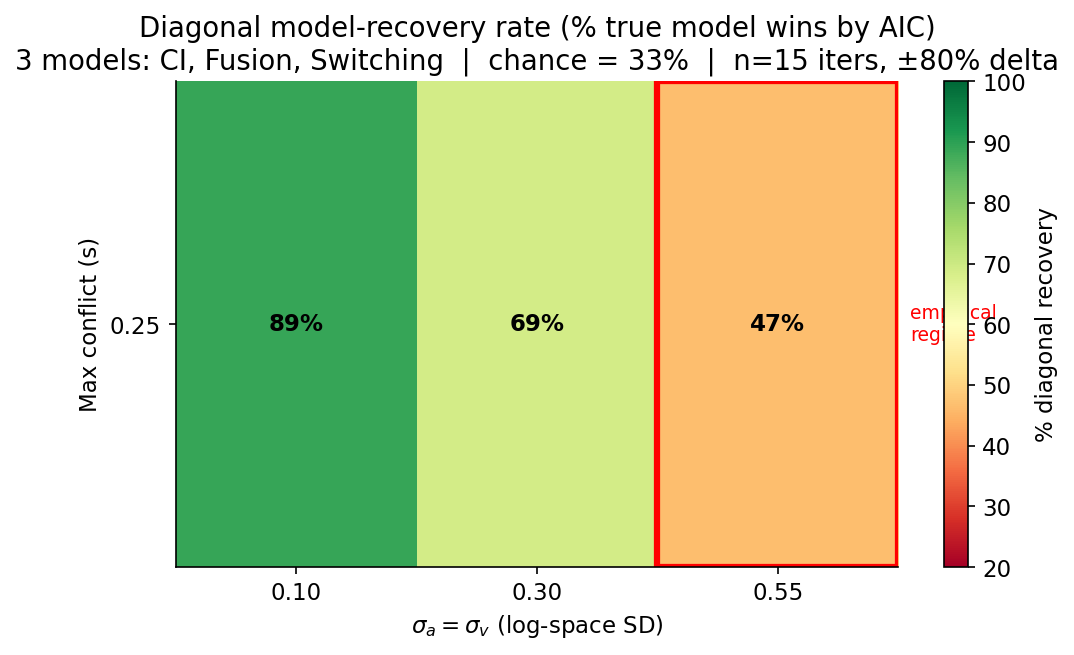

In [22]:
with open('identifiability_sweep_results_v2/identifiability_sweep_summary.json') as f:
    sweep = json.load(f)

grid = pd.DataFrame(sweep['grid'])
sigmas = sorted(grid['sigma_a'].unique())
cmaxes = sorted(grid['conflict_max'].unique(), reverse=True)

Z = np.zeros((len(cmaxes), len(sigmas)))
for i, cm in enumerate(cmaxes):
    for j, sg in enumerate(sigmas):
        row = grid[(grid['sigma_a']==sg) & (grid['conflict_max']==cm)]
        Z[i, j] = row['mean_diag_recovery_aic'].iloc[0] if len(row) else np.nan

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(Z * 100, aspect='auto', cmap='RdYlGn', vmin=20, vmax=100)
ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([f'{v:.2f}' for v in sigmas])
ax.set_yticks(range(len(cmaxes)))
ax.set_yticklabels([f'{v:.2f}' for v in cmaxes])
ax.set_xlabel(r'$\sigma_a = \sigma_v$ (log-space SD)')
ax.set_ylabel('Max conflict (s)')
ax.set_title('Diagonal model-recovery rate (% true model wins by AIC)\n'
              '3 models: CI, Fusion, Switching  |  chance = 33%  |  n=15 iters, ±80% delta')
for i in range(len(cmaxes)):
    for j in range(len(sigmas)):
        ax.text(j, i, f'{Z[i,j]*100:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='black')
# Empirical regime marker
sigs_arr = np.array(sigmas)
cfls_arr = np.array(cmaxes)
ci = int(np.argmin(np.abs(sigs_arr - 0.55)))
ri = int(np.argmin(np.abs(cfls_arr - 0.25)))
ax.add_patch(plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                             fill=False, edgecolor='red', lw=3))
ax.text(ci+0.55, ri, 'empirical\nregime', color='red', fontsize=9, va='center')
fig.colorbar(im, ax=ax, label='% diagonal recovery')
plt.tight_layout()
plt.savefig('identifiability_figures/fig_diagonal_recovery_heatmap.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_diagonal_recovery_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()

## 6. Per-model diagonal recovery

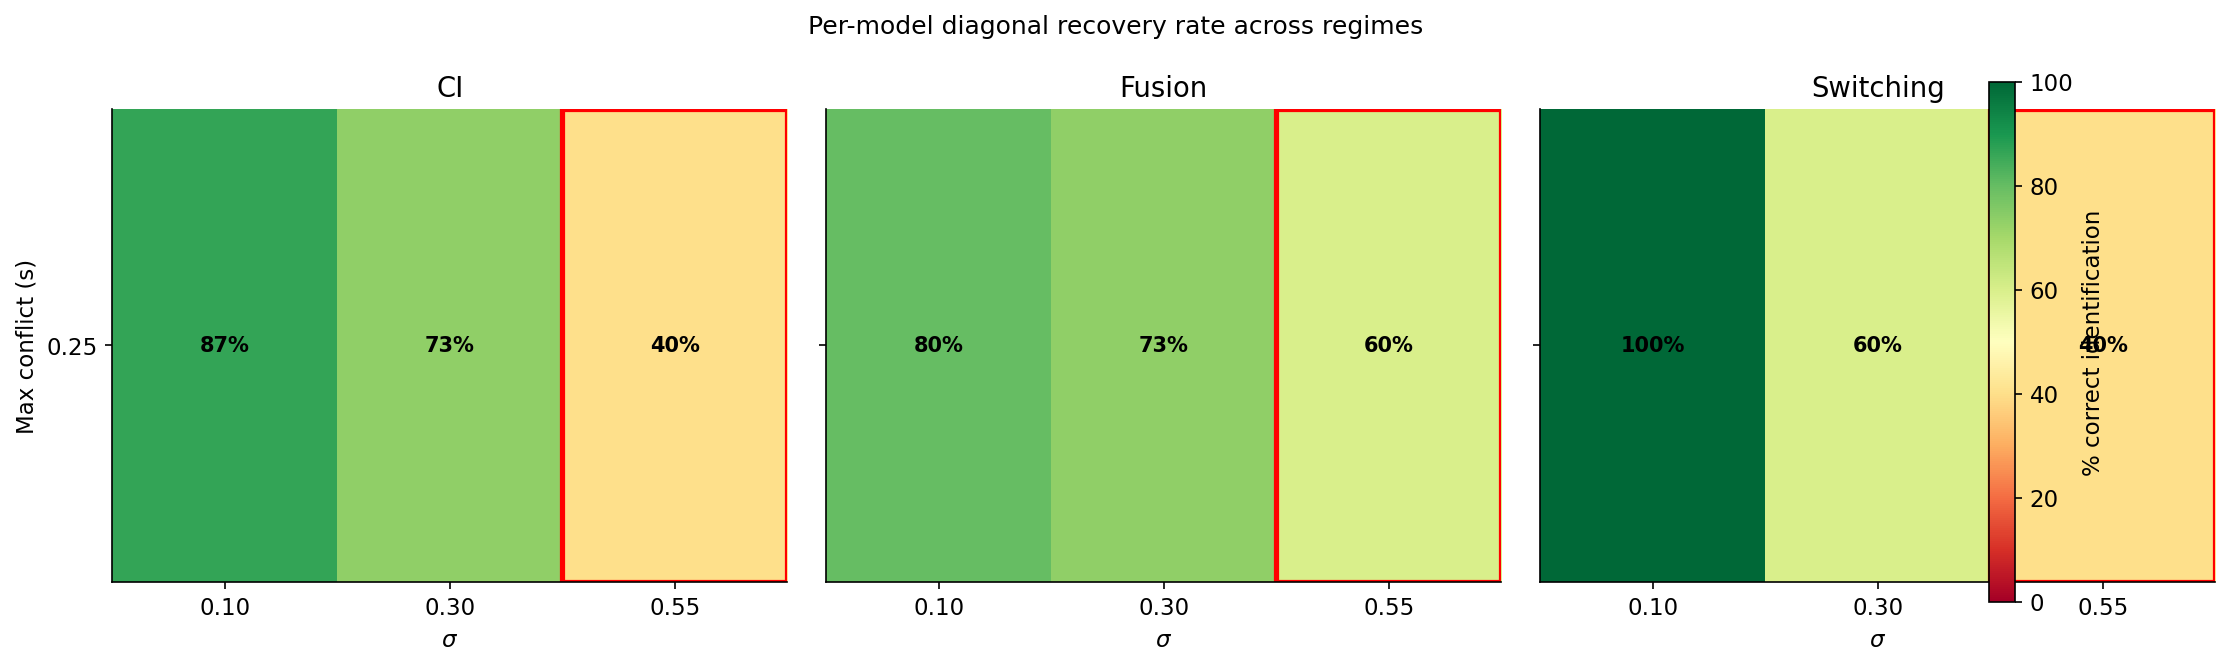

In [23]:
models_in_sweep = sweep['grid'][0]['per_model_diag_aic'].keys() if sweep['grid'] else []
model_list = list(models_in_sweep)

fig, axes = plt.subplots(1, len(model_list), figsize=(5*len(model_list), 4.5), sharey=True)
if len(model_list) == 1:
    axes = [axes]

for ax, model in zip(axes, model_list):
    Zm = np.zeros((len(cmaxes), len(sigmas)))
    for i, cm in enumerate(cmaxes):
        for j, sg in enumerate(sigmas):
            row = grid[(grid['sigma_a']==sg) & (grid['conflict_max']==cm)]
            if len(row):
                Zm[i, j] = row['per_model_diag_aic'].iloc[0].get(model, 0)
    im = ax.imshow(Zm * 100, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    ax.set_xticks(range(len(sigmas)))
    ax.set_xticklabels([f'{v:.2f}' for v in sigmas])
    ax.set_yticks(range(len(cmaxes)))
    ax.set_yticklabels([f'{v:.2f}' for v in cmaxes])
    ax.set_xlabel(r'$\sigma$')
    if ax == axes[0]:
        ax.set_ylabel('Max conflict (s)')
    ax.set_title(MODEL_ABBR.get(model, model))
    for i in range(len(cmaxes)):
        for j in range(len(sigmas)):
            ax.text(j, i, f'{Zm[i,j]*100:.0f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold')
    # empirical marker
    ax.add_patch(plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                                fill=False, edgecolor='red', lw=2.5))

fig.suptitle('Per-model diagonal recovery rate across regimes', fontsize=12)
fig.colorbar(im, ax=axes, fraction=0.015, label='% correct identification')
plt.tight_layout()
plt.savefig('identifiability_figures/fig_per_model_recovery.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_per_model_recovery.png', bbox_inches='tight', dpi=200)
plt.show()

## 7. Confusion matrices across regimes

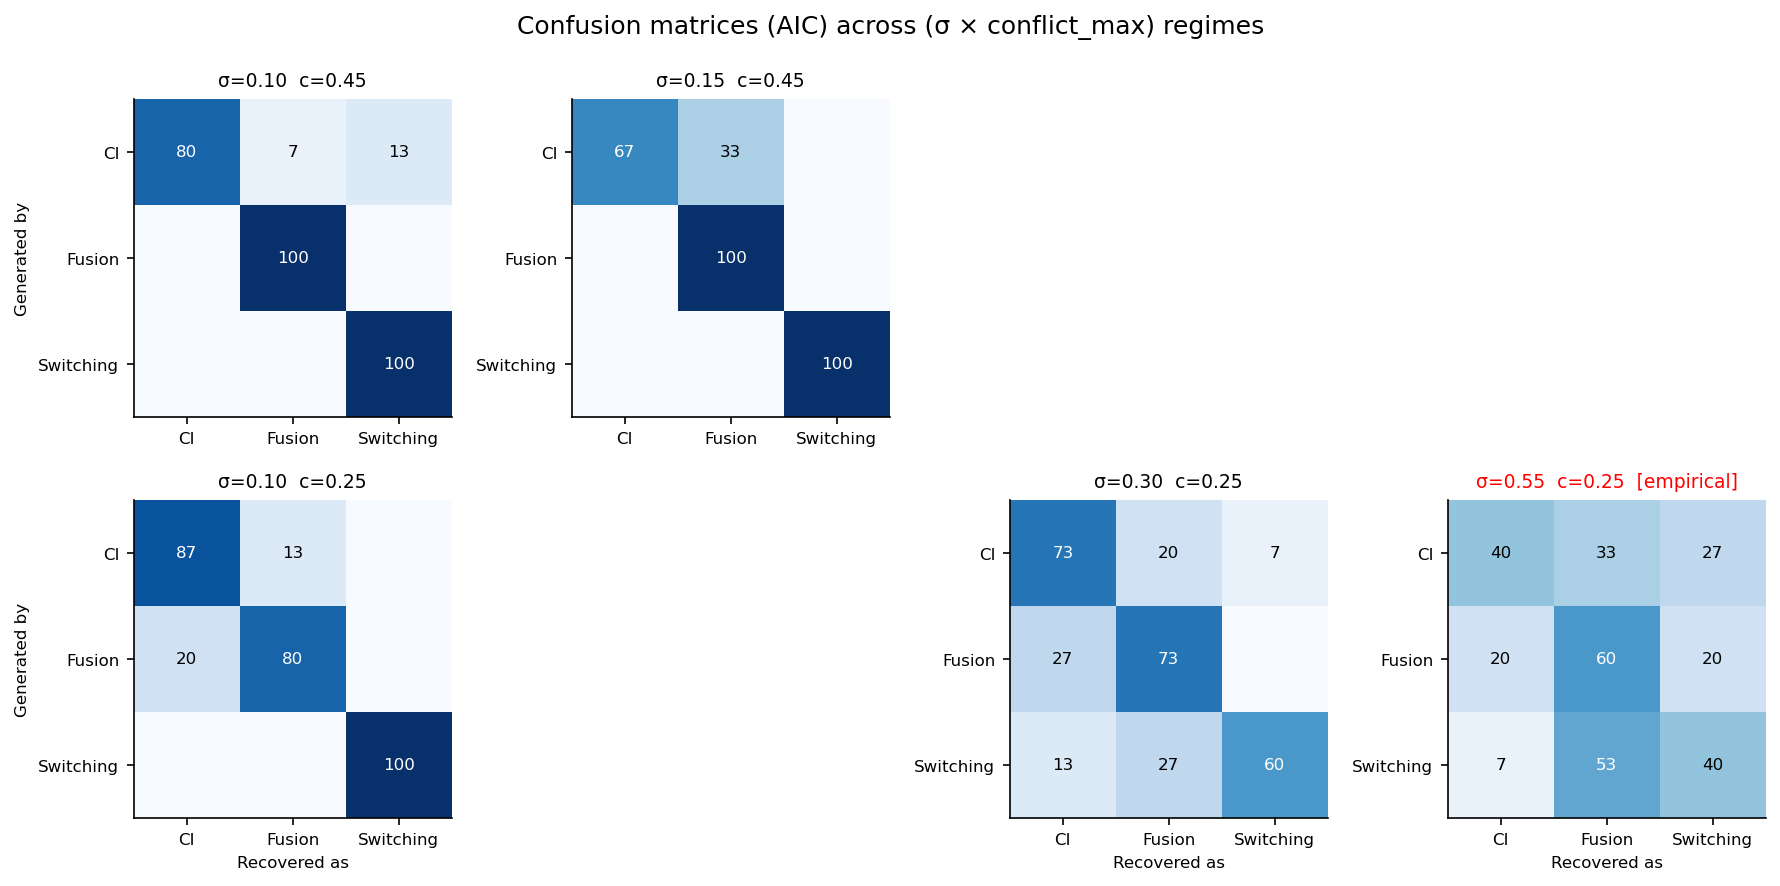

In [24]:
cells = []
for fp in sorted(glob.glob('identifiability_sweep_results_v2/cell_*.json')):
    with open(fp) as f:
        cells.append(json.load(f))

if not cells:
    print('No cell files found.')
else:
    cell_sigmas  = sorted({c['sigma_a'] for c in cells})
    cell_cmaxes  = sorted({c['conflict_max'] for c in cells}, reverse=True)
    sweep_models = cells[0]['models']
    abbrs        = [MODEL_ABBR.get(m, m[:3]) for m in sweep_models]
    nm = len(sweep_models)

    nrows, ncols = len(cell_cmaxes), len(cell_sigmas)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows), squeeze=False)

    for i, cm in enumerate(cell_cmaxes):
        for j, sg in enumerate(cell_sigmas):
            ax = axes[i][j]
            cell = next((c for c in cells
                          if np.isclose(c['sigma_a'], sg) and np.isclose(c['conflict_max'], cm)), None)
            if cell is None:
                ax.set_visible(False)
                continue
            mat = np.zeros((nm, nm))
            for ii, gen in enumerate(sweep_models):
                row = cell['confusion_aic'].get(gen, {})
                tot = sum(row.values()) or 1
                for jj, fit in enumerate(sweep_models):
                    mat[ii, jj] = row.get(fit, 0) / tot
            im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(nm)); ax.set_xticklabels(abbrs, fontsize=8)
            ax.set_yticks(range(nm)); ax.set_yticklabels(abbrs, fontsize=8)
            for ii in range(nm):
                for jj in range(nm):
                    if mat[ii, jj] > 0.05:
                        ax.text(jj, ii, f'{mat[ii,jj]*100:.0f}',
                                ha='center', va='center', fontsize=8,
                                color='white' if mat[ii,jj]>0.5 else 'black')
            is_emp = np.isclose(sg, 0.55) and np.isclose(cm, 0.25)
            ax.set_title(f'σ={sg:.2f}  c={cm:.2f}' + ('  [empirical]' if is_emp else ''),
                          fontsize=9, color='red' if is_emp else 'black')
            if j == 0: ax.set_ylabel('Generated by', fontsize=8)
            if i == nrows-1: ax.set_xlabel('Recovered as', fontsize=8)

    fig.suptitle('Confusion matrices (AIC) across (σ × conflict_max) regimes', fontsize=12)
    plt.tight_layout()
    plt.savefig('identifiability_figures/fig_confusion_matrices.pdf', bbox_inches='tight')
    plt.savefig('identifiability_figures/fig_confusion_matrices.png', bbox_inches='tight', dpi=200)
    plt.show()

## 8. PSE-curve separation by regime

Showing why the models are hard to distinguish: with empirical noise the predicted PSE curves are nearly identical, whereas lowering σ (and optionally extending conflict) separates them dramatically.

In [ ]:
import sys
sys.path.insert(0, '.')
import compute_model_divergence as cmd

REGIMES = [
    ('Empirical\n(σ≈0.55, |c|≤0.25)',   0.55, 0.25),
    ('Low noise\n(σ=0.10, |c|≤0.25)',    0.10, 0.25),
    ('Low noise + wide\n(σ=0.10, |c|≤0.60)', 0.10, 0.60),
]
M_COLORS = {'lognorm': 'C0', 'fusionOnlyLogNorm': 'C1', 'switchingFree': 'C2',
             'probabilityMatchingLogNorm': 'C3', 'selection': 'C4'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax, (label, sigma, cmax) in zip(axes, REGIMES):
    template = cmd.build_template(conflict_max=cmax, n_conflict_steps=13,
                                   n_delta_steps=15, n_trials_per_cell=4)
    for model in cmd.DEFAULT_MODELS:
        params = cmd.build_param_vector(model, sigma_a=sigma, sigma_v=sigma,
                                         p_c=0.5, lambda_=0.05)
        preds = cmd.predicted_p_longer(model, params, template)
        preds_snr = preds[np.isclose(preds['audNoise'], 1.2)]
        pse_per_conflict = []
        for c in sorted(preds_snr['conflictDur'].unique()):
            s = preds_snr[preds_snr['conflictDur']==c].sort_values('deltaDurS')
            ps = s['p_longer'].values
            ds = s['deltaDurS'].values * 1000
            pse = float(np.interp(0.5, ps, ds)) if ps.min()<=0.5<=ps.max() \
                  else ds[np.argmin(np.abs(ps-0.5))]
            pse_per_conflict.append((c*1000, pse))
        arr = np.array(pse_per_conflict)
        ax.plot(arr[:,0], arr[:,1], 'o-', color=M_COLORS[model],
                label=MODEL_ABBR[model], lw=2, ms=5)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Conflict (ms)')
    ax.set_ylabel('PSE shift (ms)')
    ax.set_title(label, fontsize=10)
    ax.grid(alpha=0.25)
    # shade empirical conflict range
    ax.axvspan(-250, 250, color='orange', alpha=0.06, label='empirical range (±250ms)')

axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Predicted PSE curves: models are nearly identical in the empirical regime',
              fontsize=12)
plt.tight_layout()
plt.savefig('identifiability_figures/fig_pse_curves_by_regime.pdf', bbox_inches='tight')
plt.savefig('identifiability_figures/fig_pse_curves_by_regime.png', bbox_inches='tight', dpi=200)
plt.show()

## 9. Summary: what experimental design would work?

Results below use ±80% Δ-duration range (matching real staircase) and conflict_max = 0.25 s, n = 15 iterations per generating model.

| Parameter | Empirical | Required for ≥70% recovery |
|-----------|-----------|-----------------------------|
| σ_a (log-space) | 0.28–0.82 (mean ≈ 0.55) | **≤ 0.30** |
| σ_v (log-space) | 0.14–1.84 (mean ≈ 0.57) | **≤ 0.30** |
| Max AV conflict | ±250 ms | ±250 ms is sufficient if σ is reduced |
| Diagonal recovery (3 models) | **~47%** (chance=33%) | **≥70%** |

**Key results (v2 sweep, ±80% delta):**

| σ | conflict_max | Mean diag | CI | Fusion | SwF |
|---|-------------|-----------|-----|--------|-----|
| 0.10 | 0.25 s | **89%** | 87% | 80% | 100% |
| 0.30 | 0.25 s | **69%** | 73% | 73% | 60% |
| 0.55 (empirical) | 0.25 s | **47%** | 40% | 60% | 40% |

**Practical implications:**
- Lower sensory noise requires higher-precision stimuli (e.g., ramp-duration discrimination with more training, 2-down-1-up staircase targeting 71% threshold)
- σ ≈ 0.30 is achievable with moderately practised observers and is sufficient for ~70% recovery
- σ ≈ 0.10 (Weber fraction ~10%) gives excellent recovery (89%) but requires highly practised observers
- Extending conflict range beyond ±250 ms gives only marginal improvement; reducing σ is the critical lever
- SwF is most often confused with Fusion at high noise (partial vs full integration are hard to distinguish)


In [ ]:
# Print a compact summary table
print('='*65)
print('IDENTIFIABILITY SWEEP — KEY RESULTS')
print('='*65)
print(f'{"sigma":>8}  {"conflict_max":>13}  {"mean_diag":>10}  {"CI":>6}  {"Fus":>6}  {"Swi":>6}')
print('-'*65)
for _, row in grid.sort_values(['sigma_a','conflict_max']).iterrows():
    p = row['per_model_diag_aic']
    keys = list(p.keys())
    ci_k  = next((k for k in keys if 'lognorm'   in k and 'prob' not in k and 'select' not in k), None)
    fus_k = next((k for k in keys if 'fusion'    in k.lower()), None)
    sw_k  = next((k for k in keys if 'switching' in k.lower()), None)
    emp = '  <-- empirical' if np.isclose(row['sigma_a'],0.55) and np.isclose(row['conflict_max'],0.25) else ''
    print(f"{row['sigma_a']:>8.2f}  {row['conflict_max']:>13.2f}  "
          f"{row['mean_diag_recovery_aic']*100:>9.1f}%  "
          f"{(p.get(ci_k,0) if ci_k else 0)*100:>5.0f}%  "
          f"{(p.get(fus_k,0) if fus_k else 0)*100:>5.0f}%  "
          f"{(p.get(sw_k,0) if sw_k else 0)*100:>5.0f}%{emp}")
print('='*65)

IDENTIFIABILITY SWEEP — KEY RESULTS
   sigma   conflict_max   mean_diag      CI     Fus     Swi
-----------------------------------------------------------------
    0.10           0.25       88.9%     87%     80%    100%
    0.30           0.25       68.9%     73%     73%     60%
    0.55           0.25       46.7%     40%     60%     40%  <-- empirical
